<a href="https://colab.research.google.com/github/IssarapongB/BasicPython/blob/main/99424_LAB_ACTIVITY4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
mydata= pd.read_csv('/content/drive/MyDrive/99424_1/Train_students.csv')
mydata.head(10)

,SchoolType,Age,Gender,Eng,Thai,Social,Math,Sci,Passed
0,Public,17,F,26,19,33,34,20,No
1,Public,18,M,33,50,50,15,19,No
2,Public,16,F,26,19,33,25,31,No
3,Public,16,F,55,55,60,22,27,No
4,Public,16,M,21,19,60,20,32,No
5,Public,16,M,40,55,21,29,39,No
6,Public,16,F,26,40,33,15,23,No
7,Public,16,F,39,19,40,20,18,No
8,Public,16,F,28,60,23,22,26,No
9,Public,16,F,35,45,30,17,30,No


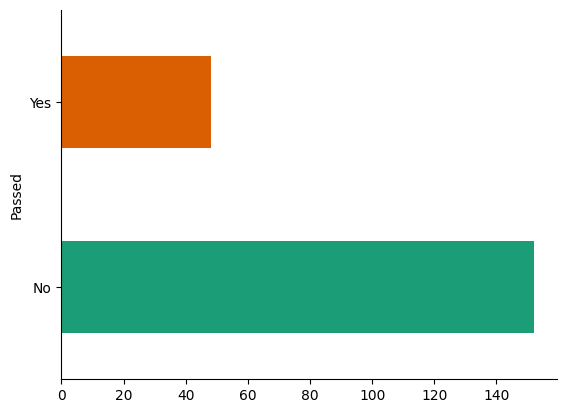

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
mydata.groupby('Passed').size().plot(kind='barh',
  color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
all_features = [name for name in mydata.columns if
                mydata[name].dtype == 'object']
all_features

['SchoolType', 'Gender', 'Passed']

In [ ]:
all_features=[name for name in mydata.columns if
              mydata[name].dtype =='object']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in list(all_features):
  mydata[i]=le.fit_transform(mydata[i])
for x in all_features:
  print(x," = ",mydata[x].unique())

SchoolType  =  [1 0]
Gender  =  [0 1]
Passed  =  [0 1]


In [ ]:
mydata.head(10)

,SchoolType,Age,Gender,Eng,Thai,Social,Math,Sci,Passed
0,1,17,0,26,19,33,34,20,0
1,1,18,1,33,50,50,15,19,0
2,1,16,0,26,19,33,25,31,0
3,1,16,0,55,55,60,22,27,0
4,1,16,1,21,19,60,20,32,0
5,1,16,1,40,55,21,29,39,0
6,1,16,0,26,40,33,15,23,0
7,1,16,0,39,19,40,20,18,0
8,1,16,0,28,60,23,22,26,0
9,1,16,0,35,45,30,17,30,0


In [ ]:
from sklearn.feature_selection import chi2
X = mydata.drop('Passed', axis=1)
y = mydata['Passed']
chi_scores = chi2(X, y)
chi_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores[0],
    'P-value': chi_scores[1]
})
chi_results = chi_results.sort_values(
    by='Chi2 Score',
    ascending=False
)
print(chi_results)

      Feature  Chi2 Score       P-value
6        Math  376.195290  8.381414e-84
7         Sci  235.299715  4.165037e-53
4        Thai   32.567136  1.151454e-08
3         Eng    6.664108  9.837386e-03
2      Gender    5.120638  2.364293e-02
5      Social    2.305281  1.289350e-01
0  SchoolType    1.483904  2.231647e-01
1         Age    0.011354  9.151403e-01


In [ ]:
from sklearn.model_selection import train_test_split
X_new = mydata[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]
y_new= mydata['Passed']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. เตรียมข้อมูลฟีเจอร์เด่นจากกิจกรรมที่ 4
X_new = mydata[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]
y_new = mydata['Passed']

# 2. กำหนดสัดส่วน test_size ที่เราอยากให้อัลกอริทึมทดลองวิ่งหา
test_sizes = [0.15, 0.20, 0.25, 0.30, 0.35]

# 3. กำหนดรายชื่อโมเดลและช่วงพารามิเตอร์ที่ต้องการปรับจูนผ่าน GridSearchCV
models_and_params = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, 5, 7]}
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [10, 50, 100], 'max_depth': [None, 5, 10]}
    },
    'Naïve Bayes': {
        'model': GaussianNB(),
        'params': {} # Naïve Bayes ปกติไม่มีไฮเปอร์พารามิเตอร์หลักให้จูน
    }
}

# ตัวแปรสำหรับเก็บผลลัพธ์ที่ดีที่สุดในการทดลองทั้งหมด
best_overall_accuracy = 0
best_overall_report = {}

print("⏳ กำลังเริ่มระบบค้นหาแบบจำลองและสัดส่วนข้อมูลที่เหมาะสมที่สุดอัตโนมัติ...\n")

# 4. ลูปชั้นนอก: ทดลองเปลี่ยนสัดส่วนข้อมูล (test_size)
for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=size, random_state=1)

    # ลูปชั้นใน: ทดลองจูนพารามิเตอร์ของแต่ละโมเดลผ่าน GridSearchCV
    for model_name, config in models_and_params.items():
        grid = GridSearchCV(config['model'], config['params'], scoring='accuracy', cv=5, n_jobs=-1)
        grid.fit(X_train, y_train)

        # นำโมเดลตัวที่ดีที่สุดจากการจูน (Best Estimator) มาทดสอบกับ X_test ในรอบนั้น
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # หากได้ค่า Accuracy สูงกว่าสถิติเดิม ให้บันทึกค่าเก็บไว้
        if acc > best_overall_accuracy:
            best_overall_accuracy = acc
            best_overall_report = {
                'Model': model_name,
                'Test Size': size,
                'Train Size': 1 - size,
                'Best Params': grid.best_params_,
                'Accuracy': acc
            }

# 5. แสดงบทสรุปผลลัพธ์ที่ดีที่สุดจากการคำนวณทั้งหมด
print("="*60)
print("🎯 บทสรุปผลการค้นหาโมเดลและสัดส่วนข้อมูลที่ดีที่สุด 🎯")
print("="*60)
print(f"🔹 โมเดลที่ควรเลือกใช้ (Best Model): {best_overall_report['Model']}")
print(f"🔹 สัดส่วนข้อมูลชุดทดสอบ (Best test_size): {best_overall_report['Test Size']} ({best_overall_report['Test Size']*100:.0f}%)")
print(f"🔹 สัดส่วนข้อมูลชุดฝึกสอน (Best train_size): {best_overall_report['Train Size']} ({best_overall_report['Train Size']*100:.0f}%)")
print(f"🔹 พารามิเตอร์ที่เหมาะสมของโมเดลนี้ (Best Params): {best_overall_report['Best Params']}")
print(f"🔹 ค่าความถูกต้องสูงสุดที่ทำได้ (Max Accuracy): {best_overall_report['Accuracy']*100:.2f}%")
print("="*60)

⏳ กำลังเริ่มระบบค้นหาแบบจำลองและสัดส่วนข้อมูลที่เหมาะสมที่สุดอัตโนมัติ...

🎯 บทสรุปผลการค้นหาโมเดลและสัดส่วนข้อมูลที่ดีที่สุด 🎯
🔹 โมเดลที่ควรเลือกใช้ (Best Model): Random Forest
🔹 สัดส่วนข้อมูลชุดทดสอบ (Best test_size): 0.3 (30%)
🔹 สัดส่วนข้อมูลชุดฝึกสอน (Best train_size): 0.7 (70%)
🔹 พารามิเตอร์ที่เหมาะสมของโมเดลนี้ (Best Params): {'max_depth': 5, 'n_estimators': 100}
🔹 ค่าความถูกต้องสูงสุดที่ทำได้ (Max Accuracy): 91.67%


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3 , random_state=1)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

def test_model(model, model_name):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print("="*50)
  print("Model:", model_name)
  print("\nConfusion Matrix")
  print(confusion_matrix(y_test, y_pred))
  print("\nClassification Report")
  print(classification_report(y_test, y_pred))
  print("\nAccuracy")
  print(accuracy_score(y_test, y_pred))

In [ ]:
## 4.11. นศ. เขียนคำสั่งสร้าง model ด้วย Decision Tree
from sklearn.tree import DecisionTreeClassifier
modelDT = DecisionTreeClassifier(random_state=42)
modelDT.fit(X_train, y_train)
test_model(modelDT, "Decision Tree")

Model: Decision Tree

Confusion Matrix
[[42  5]
 [ 5  8]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        47
           1       0.62      0.62      0.62        13

    accuracy                           0.83        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.83      0.83      0.83        60


Accuracy
0.8333333333333334


In [ ]:
# 4.12. นศ. เขียนคำสั่งสร้าง model ด้วย SVM
from sklearn.svm import SVC
modelSVM = SVC(random_state=42)
test_model(modelSVM, "SVM")

Model: SVM

Confusion Matrix
[[47  0]
 [ 7  6]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        47
           1       1.00      0.46      0.63        13

    accuracy                           0.88        60
   macro avg       0.94      0.73      0.78        60
weighted avg       0.90      0.88      0.87        60


Accuracy
0.8833333333333333


In [ ]:
# 4.13. นศ. เขียนคำสั่งสร้าง model ด้วย Random Forest
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(random_state=42)
test_model(modelRF, "Random Forest")

Model: Random Forest

Confusion Matrix
[[46  1]
 [ 6  7]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        47
           1       0.88      0.54      0.67        13

    accuracy                           0.88        60
   macro avg       0.88      0.76      0.80        60
weighted avg       0.88      0.88      0.87        60


Accuracy
0.8833333333333333


In [ ]:
# 4.14. นศ. เขียนคำสั่งสร้าง model ด้วย Naïve Bayes
from sklearn.naive_bayes import GaussianNB
modelNB = GaussianNB()
test_model(modelNB, "Naïve Bayes")

Model: Naïve Bayes

Confusion Matrix
[[44  3]
 [ 5  8]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        47
           1       0.73      0.62      0.67        13

    accuracy                           0.87        60
   macro avg       0.81      0.78      0.79        60
weighted avg       0.86      0.87      0.86        60


Accuracy
0.8666666666666667


In [ ]:
# 4.16. อ่านข้อมูลสำหรับทดสอบแบบจำลอง
test_students = pd.read_csv('/content/drive/MyDrive/99424_1/Test_students.csv')

# ดึงเฉพาะคุณลักษณะ 6 ตัวแปรหลักให้เหมือนตอน Train โมเดล
X_test_new = test_students[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]

# 4.17. ทำนายผลลัพธ์ด้วย DT และสร้างคอลัมน์ใหม่
test_students["Predicted_Result"] = modelDT.predict(X_test_new)
print(test_students.head())

# 4.18. บันทึกผลลัพธ์ลงไฟล์ CSV
test_students.to_csv('/content/sample_data/Test_students_Result.csv', index=False)

   SchoolType  Eng  Thai  Social  Math  Sci  Predicted_Result
0           0   26    19      33    34   20                 0
1           1   50    59      45    42   20                 1
2           0   58    60      65    22   30                 1
3           0   49    70      55    20   30                 0
4           0   88    35      60    25   62                 1


In [ ]:
# 4.16. อ่านข้อมูลสำหรับทดสอบแบบจำลอง
test_students = pd.read_csv('/content/drive/MyDrive/99424_1/Test_students.csv')

# ดึงเฉพาะคุณลักษณะ 6 ตัวแปรหลักให้เหมือนตอน Train โมเดล
X_test_new = test_students[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]

# 4.17. ทำนายผลลัพธ์ด้วย SVM และสร้างคอลัมน์ใหม่
test_students["Predicted_Result"] = modelSVM.predict(X_test_new)
print(test_students.head())

# 4.18. บันทึกผลลัพธ์ลงไฟล์ CSV
test_students.to_csv('/content/sample_data/Test_students_Result.csv', index=False)

   SchoolType  Eng  Thai  Social  Math  Sci  Predicted_Result
0           0   26    19      33    34   20                 0
1           1   50    59      45    42   20                 1
2           0   58    60      65    22   30                 0
3           0   49    70      55    20   30                 0
4           0   88    35      60    25   62                 1


In [ ]:
# 4.16. อ่านข้อมูลสำหรับทดสอบแบบจำลอง
test_students = pd.read_csv('/content/drive/MyDrive/99424_1/Test_students.csv')

# ดึงเฉพาะคุณลักษณะ 6 ตัวแปรหลักให้เหมือนตอน Train โมเดล
X_test_new = test_students[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]

# 4.17. ทำนายผลลัพธ์ด้วย RF และสร้างคอลัมน์ใหม่
test_students["Predicted_Result"] = modelRF.predict(X_test_new)
print(test_students.head())

# 4.18. บันทึกผลลัพธ์ลงไฟล์ CSV
test_students.to_csv('/content/sample_data/Test_students_Result.csv', index=False)

   SchoolType  Eng  Thai  Social  Math  Sci  Predicted_Result
0           0   26    19      33    34   20                 0
1           1   50    59      45    42   20                 1
2           0   58    60      65    22   30                 1
3           0   49    70      55    20   30                 0
4           0   88    35      60    25   62                 1


In [ ]:
# 4.16. อ่านข้อมูลสำหรับทดสอบแบบจำลอง
test_students = pd.read_csv('/content/drive/MyDrive/99424_1/Test_students.csv')

# ดึงเฉพาะคุณลักษณะ 6 ตัวแปรหลักให้เหมือนตอน Train โมเดล
X_test_new = test_students[['SchoolType', 'Eng', 'Thai', 'Social', 'Math', 'Sci']]

# 4.17. ทำนายผลลัพธ์ด้วย RF และสร้างคอลัมน์ใหม่
test_students["Predicted_Result"] = modelNB.predict(X_test_new)
print(test_students.head())

# 4.18. บันทึกผลลัพธ์ลงไฟล์ CSV
test_students.to_csv('/content/sample_data/Test_students_Result.csv', index=False)

   SchoolType  Eng  Thai  Social  Math  Sci  Predicted_Result
0           0   26    19      33    34   20                 0
1           1   50    59      45    42   20                 1
2           0   58    60      65    22   30                 0
3           0   49    70      55    20   30                 0
4           0   88    35      60    25   62                 1
